# Coleta e Tratamento de Dados — Níveis Fluviométricos das Capitais da Região Norte

**Trabalho 1 — Aquisição de Dados** | Ciência de Dados — UFAM/ICOMP  
**Professor:** André Carvalho  
**Fonte:** API HidroWebService — Agência Nacional de Águas (ANA)  
**Método de coleta:** API autenticada (REST)  
**Período dos dados:** 2021–2026  
**Escopo:** Estações fluviométricas localizadas nas capitais da Região Norte (Manaus, Boa Vista, Belém, Rio Branco, Porto Velho, Macapá e Palmas) — apenas as capitais com estação disponível entram na base final.

---

## O que este notebook faz?

Este notebook executa **toda a pipeline** de coleta e tratamento de dados hidrológicos, do zero até a base final pronta para análise. Ele é **autocontido** — não depende de scripts externos.

Diferente de uma coleta genérica da Região Norte inteira (que envolveria ~1.771 estações), este notebook é **focado desde o início** nas estações fluviométricas localizadas nas 7 capitais estaduais da região. O filtro por capital é aplicado logo na Etapa 1, antes da coleta de séries históricas — assim, todas as etapas seguintes (coleta de cotas, tratamento e análise exploratória) trabalham só com esse subconjunto, o que torna a coleta muito mais rápida e o notebook mais fácil de rodar do início ao fim.

### Pipeline resumida:

```
API da ANA (internet)
    │
    ▼
┌─────────────────────────────────┐
│  ETAPA 1 — Explorar Estações   │  Autentica na API → busca inventário
│  (quais estações existem?)     │  → filtra fluviométricas do Norte
│                                 │  → filtra apenas as das 7 capitais
└───────────────┬─────────────────┘
                ▼
┌─────────────────────────────────┐
│  ETAPA 2 — Coletar Cotas       │  Para cada estação de capital, baixa
│  (nível do rio, dia a dia)     │  os dados de nível do rio (2021–2026)
└───────────────┬─────────────────┘
                ▼
┌─────────────────────────────────┐
│  ETAPA 3 — Tratar Dados        │  Melt/Unpivot do formato largo →
│  (limpar, padronizar)          │  formato longo (1 linha por dia)
└───────────────┬─────────────────┘
                ▼
┌─────────────────────────────────┐
│  ETAPA 4 — Análise Exploratória│  Gráficos, estatísticas,
│  (visualizar e entender)       │  qualidade dos dados
└─────────────────────────────────┘
```

### Capitais da Região Norte consideradas

| UF | Capital |
|----|---------|
| AM | Manaus |
| PA | Belém |
| RO | Porto Velho |
| RR | Boa Vista |
| AC | Rio Branco |
| AP | Macapá |
| TO | Palmas |

> **Nem toda capital tem estação fluviométrica cadastrada na ANA.** O notebook trabalha apenas com as capitais que **efetivamente têm** estação(ões) fluviométrica(s) disponível(is) no inventário — as demais são reportadas como ausentes, mas não impedem a execução do restante do pipeline.

### Chave de integração com a equipe

A coluna **`data`** (formato `YYYY-MM-DD`) é a variável em comum para cruzar estes dados de nível do rio com os **dados de preços de produtos** coletados pelos outros membros da equipe.

> **⚠️ Atenção:** A coleta faz requisições reais à API da ANA. Como o escopo agora é limitado às estações das capitais (tipicamente poucas dezenas, no máximo), a coleta é bem mais rápida do que buscar a Região Norte inteira. Ainda assim, respeite as pausas entre requisições (ética de coleta).

---

## 1. Instalação e Importações

Antes de tudo, precisamos garantir que as bibliotecas necessárias estejam instaladas. O Google Colab já vem com `pandas`, `matplotlib` e `numpy`, mas precisamos instalar:

- **`pyarrow`** — motor para salvar dados em formato Parquet (formato binário compacto, muito usado em ciência de dados)
- **`requests`** — biblioteca para fazer requisições HTTP à API da ANA

O comando `!pip install -q` instala silenciosamente (o `-q` suprime a saída detalhada).

In [ ]:
# Instala dependências (Colab já tem pandas e matplotlib)
!pip install -q pyarrow requests python-dotenv

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import json
import os
import time
import calendar
from datetime import datetime, timedelta
from dotenv import load_dotenv
load_dotenv()

# Configurações de exibição
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Bibliotecas carregadas.")

---

## 2. Configuração

Aqui definimos todas as **constantes** que controlam a coleta. É a única célula que você precisa editar se quiser ajustar o comportamento:

- **Credenciais:** CPF e senha cadastrados no portal HidroWebService da ANA (cadastro gratuito em [ana.gov.br/hidrowebservice](https://www.ana.gov.br/hidrowebservice/))
- **`UFS_NORTE`:** Lista das 7 Unidades Federativas da Região Norte — a API exige buscar estado por estado (é o universo de onde extraímos as estações das capitais)
- **`CAPITAIS_NORTE`:** Dicionário UF → nome do município da capital. É a referência usada para filtrar apenas as estações localizadas nessas cidades
- **`ANO_INICIO` / `ANO_FIM`:** Janela temporal dos dados históricos (2021 a 2026)

Como o pipeline agora é restrito às estações das capitais (um subconjunto pequeno, tipicamente poucas dezenas de estações), **não há mais necessidade de um limite `MAX_ESTACOES`** — todas as estações de capitais encontradas são coletadas.

As pastas `dados_brutos/` e `dados_tratados/` são criadas automaticamente com `os.makedirs()`.

In [ ]:
# ============================================================
# CONFIGURAÇÃO — edite apenas esta célula
# ============================================================

# Credenciais (cadastro gratuito em https://www.ana.gov.br/hidrowebservice/)
# Carregadas do arquivo .env na raiz do projeto (load_dotenv() na célula de imports)
IDENTIFICADOR = os.environ.get("IDENTIFICADOR")   # CPF cadastrado
SENHA = os.environ.get("SENHA")             # Senha recebida por e-mail

# URL base da API
BASE_URL = "https://www.ana.gov.br/hidrowebservice"

# UFs da Região Norte (universo de busca no inventário da API)
UFS_NORTE = ["AM", "PA", "RO", "RR", "AC", "AP", "TO"]

# Capitais da Região Norte — escopo final deste notebook.
# Chave: sigla da UF | Valor: nome do município da capital (como aparece no inventário da ANA)
CAPITAIS_NORTE = {
    "AM": "Manaus",
    "PA": "Belém",
    "RO": "Porto Velho",
    "RR": "Boa Vista",
    "AC": "Rio Branco",
    "AP": "Macapá",
    "TO": "Palmas",
}

# Período de interesse
ANO_INICIO = 2021
ANO_FIM = 2026

# Pastas de saída
PASTA_DADOS_BRUTOS = os.path.join("Dados_nivel_rios", "Dados Brutos")
PASTA_DADOS_TRATADOS = os.path.join("Dados_nivel_rios", "Dados Tratados")
os.makedirs(PASTA_DADOS_BRUTOS, exist_ok=True)
os.makedirs(PASTA_DADOS_TRATADOS, exist_ok=True)

print(f"✅ Configuração carregada.")
print(f"   UFs: {UFS_NORTE}")
print(f"   Capitais-alvo: {list(CAPITAIS_NORTE.values())}")
print(f"   Período: {ANO_INICIO}–{ANO_FIM}")

---

# ETAPA 1 — Exploração e Coleta de Estações (Capitais da Região Norte)

### O que é uma estação fluviométrica?

Uma **estação fluviométrica** é um ponto de monitoramento instalado à margem de um rio, que mede o **nível da água** (cota) diariamente. A ANA mantém milhares dessas estações por todo o Brasil.

### O que esta etapa faz?

1. **Autentica** na API da ANA (obtém um token JWT válido por 60 minutos)
2. **Busca o inventário** de todas as estações, estado por estado (Região Norte)
3. **Filtra** apenas as estações **fluviométricas** (que medem nível do rio — não pluviométricas, que medem chuva)
4. **Filtra pelas 7 capitais** da Região Norte (Manaus, Belém, Porto Velho, Boa Vista, Rio Branco, Macapá, Palmas) — este é o filtro que define o escopo de **todo o restante do notebook**

### Detalhes técnicos da API

- **Autenticação:** `GET /EstacoesTelemetricas/OAUth/v1` — envia CPF e senha nos headers, recebe um token JWT
- **Inventário:** `GET /HidroInventarioEstacoes/v1` — parâmetro `"Unidade Federativa"` (nome exato da API, com espaço e acento)
- O token expira em **60 minutos**, então o script renova automaticamente quando necessário

> **Por que filtrar por UF e depois por capital, em vez de buscar direto por município?** A API da ANA só permite consultar o inventário por Unidade Federativa — não existe um parâmetro de busca por município. Por isso buscamos todas as estações de cada UF do Norte e, na sequência, filtramos localmente pelas estações cujo município é a capital do estado.

### 1.1 Funções de autenticação

A célula abaixo define duas funções:

- **`extrair_token(obj)`** — A resposta da API vem como um JSON aninhado, e o token JWT pode estar em diferentes chaves dependendo da versão da API. Esta função busca **recursivamente** por chaves como `"tokenautenticacao"`, `"token"`, `"access_token"` etc., dentro de dicionários aninhados. É uma abordagem defensiva: funciona mesmo que a ANA mude a estrutura da resposta.

- **`autenticar()`** — Faz a requisição de autenticação enviando CPF e senha como headers HTTP. Retorna o token JWT que será usado em todas as próximas requisições como `Authorization: Bearer <token>`.

> **O que é JWT?** JSON Web Token — um "passe" temporário que prova que você está autenticado. Funciona como um crachá: você mostra uma vez (CPF+senha), recebe o crachá (token), e depois só mostra o crachá nas próximas requisições.

In [ ]:
# ============================================================
# FUNÇÕES DE AUTENTICAÇÃO
# ============================================================

def extrair_token(obj):
    """Busca o token JWT recursivamente em um dict."""
    if not isinstance(obj, dict):
        return None
    for chave in ["tokenautenticacao", "token", "access_token",
                   "Token", "TokenAutenticacao", "accessToken"]:
        if chave in obj and isinstance(obj[chave], str) and len(obj[chave]) > 10:
            return obj[chave]
    for v in obj.values():
        if isinstance(v, dict):
            t = extrair_token(v)
            if t:
                return t
    return None


def autenticar() -> str:
    """
    Obtém token de autenticação da API HidroWebService.
    O token expira em 60 minutos.
    """
    url = f"{BASE_URL}/EstacoesTelemetricas/OAUth/v1"
    headers = {"Identificador": IDENTIFICADOR, "Senha": SENHA}

    print("[AUTH] Autenticando na API HidroWebService...")
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    token = None
    if isinstance(data, dict):
        token = extrair_token(data)
        if not token and "items" in data:
            items = data["items"]
            if isinstance(items, list) and len(items) > 0:
                token = extrair_token(items[0])
            elif isinstance(items, dict):
                token = extrair_token(items)
    elif isinstance(data, list) and len(data) > 0:
        token = extrair_token(data[0]) if isinstance(data[0], dict) else None
        if not token and isinstance(data[0], str) and len(data[0]) > 10:
            token = data[0]

    if not token:
        texto = json.dumps(data, ensure_ascii=False)
        print(f"[AUTH] ⚠️  Token não encontrado. Resposta: {texto[:500]}")
        raise RuntimeError("Não foi possível extrair o token. Verifique as credenciais.")

    print(f"[AUTH] ✅ Token obtido com sucesso (expira em ~60 min)")
    return token

print("Funções de autenticação definidas.")

Funções de autenticação definidas.


### 1.2 Funções de inventário de estações

A célula abaixo define duas funções:

- **`buscar_estacoes_por_uf(token, uf)`** — Faz um `GET` ao endpoint de inventário passando a UF como parâmetro. A API retorna todas as estações daquele estado (fluviométricas, pluviométricas, de qualidade da água, etc.). A função trata diferentes formatos de resposta da API (lista, dicionário com `items`, etc.) de forma robusta.

- **`filtrar_estacoes_fluviometricas(df)`** — Recebe o DataFrame com todas as estações e mantém apenas as **fluviométricas** (que medem nível do rio). O filtro busca termos como "fluv", "cota", "nível", "vazão" na coluna de tipo. Se não encontrar pelo nome, tenta pelo código numérico (`1 = fluviométrica` no padrão da ANA).

> **Por que filtrar?** A ANA tem estações de vários tipos. Nós queremos apenas as que medem **cota** (nível da água), que são as fluviométricas.

In [ ]:
# ============================================================
# INVENTÁRIO DE ESTAÇÕES
# ============================================================

def buscar_estacoes_por_uf(token: str, uf: str) -> list:
    """
    Busca estações de uma UF específica.
    Parâmetro da API: \"Unidade Federativa\" (não \"UF\").
    """
    url = f"{BASE_URL}/EstacoesTelemetricas/HidroInventarioEstacoes/v1"
    headers = {"Authorization": f"Bearer {token}"}
    params = {"Unidade Federativa": uf}

    resp = requests.get(url, headers=headers, params=params, timeout=120)

    if resp.status_code == 200:
        data = resp.json()
        if isinstance(data, dict):
            items = data.get("items")
            if isinstance(items, list):
                return items
            elif isinstance(items, dict):
                return [items]
            for chave in ["estacoes", "data", "results"]:
                if chave in data and isinstance(data[chave], list):
                    return data[chave]
            return [data] if "items" not in data else []
        elif isinstance(data, list):
            return data
    elif resp.status_code == 406:
        msg = ""
        try:
            msg = resp.json().get("message", resp.text[:200])
        except Exception:
            msg = resp.text[:200]
        print(f"  ⚠️  406 para UF={uf}: {msg}")
    else:
        print(f"  ⚠️  HTTP {resp.status_code} para UF={uf}: {resp.text[:200]}")

    return []


def filtrar_estacoes_fluviometricas(df: pd.DataFrame) -> pd.DataFrame:
    """Filtra estações fluviométricas do inventário."""
    col_tipo = None
    for candidata in ["TipoEstacao", "tipoEstacao", "Tipo", "tipo",
                       "nmTipoEstacao", "TipoEstacaoHidrologica",
                       "TipoEstacaoTelemetrica", "tipoEstacaoTelemetrica"]:
        if candidata in df.columns:
            col_tipo = candidata
            break

    if col_tipo is None:
        for col in df.columns:
            if "tipo" in col.lower():
                col_tipo = col
                break

    if col_tipo:
        print(f"[FILTRO] Coluna de tipo: '{col_tipo}'")
        tipos = df[col_tipo].dropna().unique()
        print(f"[FILTRO] Tipos disponíveis: {tipos}")

        mask = df[col_tipo].astype(str).str.lower().str.contains(
            "fluv|cota|nível|nivel|vazão|vazao|fluvio", na=False
        )
        if mask.sum() > 0:
            df_fluv = df[mask].copy()
            print(f"[FILTRO] Estações fluviométricas: {len(df_fluv)}")
            return df_fluv

    # Fallback: tipo numérico (1 = fluviométrica na ANA)
    for candidata in ["TipoEstacao", "tipoEstacao", "cdTipoEstacao"]:
        if candidata in df.columns:
            mask = df[candidata].astype(str).isin(["1", "1.0"])
            if mask.sum() > 0:
                return df[mask].copy()

    print("[FILTRO] ⚠️  Não foi possível filtrar por tipo — mantendo todas.")
    return df.copy()

print("Funções de inventário definidas.")

Funções de inventário definidas.


### 1.3 Executar Etapa 1

A célula abaixo **executa** as funções definidas acima. Passo a passo:

1. **Autentica** na API e guarda o token + timestamp (para saber quando renovar)
2. **Itera sobre cada UF** da Região Norte (AM, PA, RO, RR, AC, AP, TO), buscando as estações de cada uma com `time.sleep(1)` entre requisições (ética de coleta)
3. **Consolida** tudo em um DataFrame único (`df_todas_estacoes`)
4. **Salva** o inventário bruto em CSV (`dados_brutos/inventario_estacoes_BRUTO.csv`)
5. **Filtra** apenas as fluviométricas
6. **Filtra pelas capitais** da Região Norte definidas em `CAPITAIS_NORTE` — a partir daqui, `df_estacoes` contém **apenas** estações fluviométricas localizadas em Manaus, Belém, Porto Velho, Boa Vista, Rio Branco, Macapá e/ou Palmas (as que existirem)
7. **Salva** o inventário já filtrado em CSV
8. **Gera o arquivo de proveniência** (`proveniencia_estacoes.json`) — um registro formal de como, quando e de onde os dados foram obtidos, incluindo o filtro de capitais aplicado

> **Proveniência** é um conceito importante em ciência de dados: é o "histórico de origem" dos dados, documentando cada passo da coleta para garantir reprodutibilidade e transparência.

In [ ]:
# ============================================================
# EXECUTAR ETAPA 1 — Buscar e filtrar estações (fluviométricas + capitais do Norte)
# ============================================================

token = autenticar()
token_obtido_em = time.time()

print("\n[ESTAÇÕES] Buscando inventário de estações por UF (Região Norte)...")
todos_registros = []
for uf in UFS_NORTE:
    print(f"  [{uf}] Buscando estações...", end=" ")
    registros = buscar_estacoes_por_uf(token, uf)
    print(f"→ {len(registros)} estações")
    todos_registros.extend(registros)
    time.sleep(1)

df_todas_estacoes = pd.DataFrame(todos_registros)
print(f"\nTotal de estações na Região Norte (todos os tipos): {len(df_todas_estacoes)}")

# Salvar bruto (inventário completo, antes de qualquer filtro)
caminho_bruto = os.path.join(PASTA_DADOS_BRUTOS, "inventario_estacoes_BRUTO.csv")
df_todas_estacoes.to_csv(caminho_bruto, index=False, encoding="utf-8-sig")
print(f"[SALVO] Inventário bruto: {caminho_bruto}")

# Filtrar fluviométricas
df_fluv_norte = filtrar_estacoes_fluviometricas(df_todas_estacoes)
print(f"\n[FILTRO TIPO] Estações fluviométricas na Região Norte: {len(df_fluv_norte)}")

# ------------------------------------------------------------------
# Filtrar pelas capitais da Região Norte
# ------------------------------------------------------------------
# A partir daqui, o pipeline inteiro passa a trabalhar apenas com estações
# fluviométricas localizadas nas capitais dos estados do Norte.
capitais_alvo = [c.lower() for c in CAPITAIS_NORTE.values()]

col_municipio = None
for candidata in ["Municipio_Nome", "municipio_nome", "MunicipioNome",
                   "NomeMunicipio", "nmMunicipio", "Municipio"]:
    if candidata in df_fluv_norte.columns:
        col_municipio = candidata
        break
if col_municipio is None:
    for col in df_fluv_norte.columns:
        if "municipio" in col.lower():
            col_municipio = col
            break

if col_municipio is None:
    raise RuntimeError(
        f"Coluna de município não encontrada! Colunas disponíveis: {list(df_fluv_norte.columns)}"
    )

print(f"[FILTRO CAPITAL] Coluna de município: '{col_municipio}'")

df_estacoes = df_fluv_norte[
    df_fluv_norte[col_municipio].astype(str).str.strip().str.lower().isin(capitais_alvo)
].copy()

print(f"[FILTRO CAPITAL] Estações filtradas de {len(df_fluv_norte)} para {len(df_estacoes)} (apenas capitais do Norte).")

# Diagnóstico: quais capitais têm estação disponível e quais não têm
municipios_encontrados = sorted(df_estacoes[col_municipio].astype(str).str.strip().unique().tolist())
print(f"\n[FILTRO CAPITAL] Capitais com estação(ões) fluviométrica(s) disponível(is): {municipios_encontrados}")

capitais_sem_estacao = [
    nome for nome in CAPITAIS_NORTE.values()
    if nome.lower() not in [m.lower() for m in municipios_encontrados]
]
if capitais_sem_estacao:
    print(f"[FILTRO CAPITAL] ⚠️  Capitais SEM estação fluviométrica encontrada no inventário: {capitais_sem_estacao}")
    print("                  O pipeline seguirá normalmente apenas com as capitais disponíveis.")
else:
    print("[FILTRO CAPITAL] ✅ Todas as 7 capitais possuem ao menos uma estação fluviométrica.")

if len(df_estacoes) == 0:
    raise RuntimeError(
        "Nenhuma estação fluviométrica encontrada nas capitais da Região Norte. "
        "Verifique o nome da coluna de município ou os valores em CAPITAIS_NORTE."
    )

# Salvar inventário já filtrado (fluviométricas + capitais)
caminho_fluv = os.path.join(PASTA_DADOS_BRUTOS, "estacoes_capitais_norte_fluviometricas.csv")
df_estacoes.to_csv(caminho_fluv, index=False, encoding="utf-8-sig")
print(f"\n[SALVO] Estações filtradas (capitais do Norte): {caminho_fluv}")

# Proveniência
prov_estacoes = {
    "fonte": "API HidroWebService — ANA",
    "url": "https://www.ana.gov.br/hidrowebservice/",
    "metodo": "API autenticada (GET /HidroInventarioEstacoes/v1)",
    "data_coleta": datetime.now().isoformat(),
    "parametros": {
        "filtro_uf": UFS_NORTE,
        "param_api": "Unidade Federativa",
        "filtro_tipo_estacao": "fluviométrica",
        "filtro_municipio": list(CAPITAIS_NORTE.values()),
    },
    "resultado": {
        "n_estacoes_regiao_norte_todos_tipos": len(df_todas_estacoes),
        "n_estacoes_fluviometricas_norte": len(df_fluv_norte),
        "n_estacoes_capitais_norte": len(df_estacoes),
        "capitais_com_estacao": municipios_encontrados,
        "capitais_sem_estacao": capitais_sem_estacao,
        "colunas": list(df_estacoes.columns),
    },
    "licenca": "Dados públicos — ANA/SNIRH (Lei 9.433/1997)"
}
with open(os.path.join(PASTA_DADOS_BRUTOS, "proveniencia_estacoes.json"), "w", encoding="utf-8") as f:
    json.dump(prov_estacoes, f, ensure_ascii=False, indent=2)

print(f"\n✅ Etapa 1 concluída! {len(df_estacoes)} estações fluviométricas encontradas nas capitais da Região Norte.")

[AUTH] Autenticando na API HidroWebService...
[AUTH] ✅ Token obtido com sucesso (expira em ~60 min)

[ESTAÇÕES] Buscando inventário de estações por UF (Região Norte)...
  [AM] Buscando estações... → 648 estações
  [PA] Buscando estações... → 929 estações
  [RO] Buscando estações... → 430 estações
  [RR] Buscando estações... → 139 estações
  [AC] Buscando estações... → 152 estações
  [AP] Buscando estações... → 176 estações
  [TO] Buscando estações... → 682 estações

Total de estações na Região Norte (todos os tipos): 3156
[SALVO] Inventário bruto: dados_brutos/inventario_estacoes_BRUTO.csv
[FILTRO] Coluna de tipo: 'Tipo_Estacao'
[FILTRO] Tipos disponíveis: ['Pluviometrica' 'Fluviometrica']
[FILTRO] Estações fluviométricas: 1771

[FILTRO TIPO] Estações fluviométricas na Região Norte: 1771
[FILTRO CAPITAL] Coluna de município: 'Municipio_Nome'
[FILTRO CAPITAL] Estações filtradas de 1771 para 181 (apenas capitais do Norte).

[FILTRO CAPITAL] Capitais com estação(ões) fluviométrica(s) disp

### 1.4 Estações finais por capital

O filtro por capital já foi aplicado na célula anterior (Etapa 1, junto com o filtro de tipo fluviométrico). Esta célula apenas **visualiza** o resultado: quantas estações restaram, distribuídas por qual capital/UF, e uma amostra dos dados de cada uma.

In [ ]:
# Resumo das estações finais (já filtradas: fluviométricas + capitais do Norte)
print(f"Total de estações fluviométricas nas capitais do Norte: {len(df_estacoes)}\n")

if col_municipio in df_estacoes.columns:
    print("Distribuição por capital/município:")
    print(df_estacoes[col_municipio].value_counts())

if 'UF_Estacao' in df_estacoes.columns:
    print("\nDistribuição por UF:")
    print(df_estacoes['UF_Estacao'].value_counts().sort_index())

Total de estações fluviométricas nas capitais do Norte: 181

Distribuição por capital/município:
Municipio_Nome
MANAUS         74
PORTO VELHO    51
BOA VISTA      24
MACAPÁ         10
RIO BRANCO      9
PALMAS          9
BELÉM           4
Name: count, dtype: int64

Distribuição por UF:
UF_Estacao
AC     9
AM    74
AP    10
PA     4
RO    51
RR    24
TO     9
Name: count, dtype: int64


In [ ]:
# Tabela detalhada das estações das capitais
cols_exibir = ['codigoestacao', 'Estacao_Nome', 'Rio_Nome', 'UF_Estacao',
               'Municipio_Nome', 'Latitude', 'Longitude', 'Operando']
cols_exibir = [c for c in cols_exibir if c in df_estacoes.columns]
df_estacoes[cols_exibir]

,codigoestacao,Estacao_Nome,Rio_Nome,UF_Estacao,Municipio_Nome,Latitude,Longitude,Operando
418,14200000,FAZENDA BOM JARDIM,RIO SOLIMÕES-AMAZONAS,AM,MANAUS,-3.1833,-59.9,0
421,14210000,XIBORENINHA,RIO SOLIMÕES-AMAZONAS,AM,MANAUS,-3.2167,-59.9167,0
429,14265500,IGARAPÉ BARRO BRANCO (AV. JOSÉ LINDOSO),IGARAPÉ BARRO BRANCO,AM,MANAUS,-2.9664,-60.0022,1
430,14279000,IGARAPÉ DO FRANCO (MONTANTE),IGARAPÉ DO FRANCO,AM,MANAUS,-3.1133,-60.0356,1
431,14279050,IGARAPÉ DO FRANCO (JUSANTE),IGARAPÉ DO FRANCO,AM,MANAUS,-3.1136,-60.0317,1
...,...,...,...,...,...,...,...,...
2922,22353000,PALMAS (Distrito Taquaruçu),CÓRREGO RONCADOR,TO,PALMAS,-10.2106,-48.1958,1
2923,22354000,PALMAS (Córrego Água Fria),CÓRREGO ÁGUA FRIA,TO,PALMAS,-10.1275,-48.1881,1
2925,22355000,PALMAS (Córrego Brejo Comprido),CÓRREGO DO BREJO,TO,PALMAS,-10.0858,-48.1761,1
2931,22420000,BARRA CÓRREGO BREJO COMPRIDO,CÓRREGO BREJO COMPRIDO,TO,PALMAS,-10.18,-48.3544,1


---

# ETAPA 2 — Coleta de Séries de Cotas (Nível do Rio)

### O que são "cotas"?

**Cota** é a medida do nível da água de um rio em relação a uma referência fixa (régua). Valor em **centímetros (cm)**. Quando a cota sobe, o rio está enchendo; quando desce, está secando.

### Dois tipos de dados disponíveis

A ANA disponibiliza dois tipos de medição, cada um em um endpoint diferente:

| Tipo | Endpoint | Como é medido | Limite por requisição | Período |
|------|----------|--------------|----------------------|---------|
| **Convencional** | `HidroSerieCotas/v1` | Leitura manual diária na régua | 366 dias | Histórico completo |
| **Telemétrica** | `HidroinfoanaSerieTelemetricaAdotada/v1` | Sensor automático (várias leituras/dia) | 30 dias | Apenas dados recentes |

### ⚠️ Formato dos dados convencionais: LARGO

Os dados convencionais vêm em **formato largo** — cada linha da API representa **1 mês inteiro**, com colunas `Cota_01`, `Cota_02`, ..., `Cota_31` (uma para cada dia do mês):

```
Resposta da API (formato LARGO — 1 linha por mês):
┌────────────────────┬──────────┬──────────┬──────────┬─────┬──────────┐
│  Data_Hora_Dado    │ Cota_01  │ Cota_02  │ Cota_03  │ ... │ Cota_31  │
├────────────────────┼──────────┼──────────┼──────────┼─────┼──────────┤
│  2024-01-01 00:00  │  1234    │  1256    │  1278    │ ... │  1350    │
│  2024-02-01 00:00  │  1400    │  1420    │  1445    │ ... │  (vazio) │ ← fev não tem 31
└────────────────────┴──────────┴──────────┴──────────┴─────┴──────────┘
```

Este formato será transformado na **Etapa 3** (melt/unpivot) para o formato longo (1 linha por dia).

### Estratégia de coleta

Como o escopo já foi reduzido às estações fluviométricas das capitais do Norte (`df_estacoes`, resultado da Etapa 1), esta etapa coleta o histórico de **todas** as estações desse conjunto — sem necessidade de amostragem ou limite artificial de quantidade.

Para cada estação de capital:
1. **Convencional:** itera ano a ano (2021, 2022, ..., 2026), fazendo uma requisição por ano
2. **Telemétrica:** uma única requisição para os últimos 30 dias
3. **Pausa de 1–1.5 segundo** entre requisições (respeito ao servidor — **Requisito 3.5** do trabalho)
4. Se o token está perto de expirar (50 min), renova automaticamente

### 2.1 Funções de coleta de séries

A célula abaixo define três funções:

- **`coletar_cotas_convencional(token, codigo, data_ini, data_fim)`** — Faz `GET` ao endpoint `HidroSerieCotas/v1`. Envia o código da estação e o intervalo de datas. Retorna os dados em formato largo (Cota_01..Cota_31). Trata diferentes códigos HTTP: `200` = sucesso, `204` = sem dados, `406` = parâmetro inválido.

- **`coletar_serie_telemetrica(token, codigo, rango)`** — Faz `GET` ao endpoint telemétrico. O parâmetro `rango="DIAS_30"` pede os últimos 30 dias. Dados telemétricos têm múltiplas leituras por dia (o sensor mede automaticamente a cada poucos minutos).

- **`coletar_historico_estacao(token, codigo, ano_inicio, ano_fim)`** — Orquestra as duas funções acima. Para cada estação: coleta convencional ano a ano (2021→2022→...→2026) + telemétrica dos últimos 30 dias. Marca cada registro com `_fonte` ("convencional" ou "telemetrica") para sabermos a origem na hora do tratamento.

> **Por que ano a ano?** O endpoint convencional aceita no máximo 366 dias por requisição. Para cobrir 2021–2026, precisamos de uma chamada por ano.

In [ ]:
# ============================================================
# FUNÇÕES DE COLETA DE SÉRIES
# ============================================================

def coletar_cotas_convencional(token, codigo_estacao, data_inicial, data_final):
    """
    Coleta série de cotas convencional (medição manual).
    Endpoint: HidroSerieCotas/v1 — até 366 dias por requisição.
    Retorna formato LARGO: Cota_01..Cota_31 por mês.
    """
    url = f"{BASE_URL}/EstacoesTelemetricas/HidroSerieCotas/v1"
    headers = {"Authorization": f"Bearer {token}", "Accept": "application/json"}
    params = {
        "Código da Estação": str(codigo_estacao),
        "Tipo Filtro Data": "DATA_LEITURA",
        "Data Inicial (yyyy-MM-dd)": data_inicial,
        "Data Final (yyyy-MM-dd)": data_final,
    }

    resp = requests.get(url, headers=headers, params=params, timeout=60)

    if resp.status_code == 200:
        data = resp.json()
        if isinstance(data, list):
            return data
        elif isinstance(data, dict):
            items = data.get("items", data.get("data", data.get("results", [])))
            return items if isinstance(items, list) else ([items] if isinstance(items, dict) else [])
    elif resp.status_code == 204:
        return []
    elif resp.status_code == 406:
        try:
            msg = resp.json().get("message", "")
        except Exception:
            msg = resp.text[:200]
        print(f"    ⚠️  406: {msg}")
    else:
        print(f"    ⚠️  HTTP {resp.status_code}: {resp.text[:200]}")
    return []


def coletar_serie_telemetrica(token, codigo_estacao, rango="DIAS_30"):
    """
    Coleta série telemétrica adotada (dados automáticos recentes).
    Endpoint: HidroinfoanaSerieTelemetricaAdotada/v1 — máx DIAS_30.
    """
    url = f"{BASE_URL}/EstacoesTelemetricas/HidroinfoanaSerieTelemetricaAdotada/v1"
    headers = {"Authorization": f"Bearer {token}", "Accept": "application/json"}
    params = {
        "Código da Estação": str(codigo_estacao),
        "Tipo Filtro Data": "DATA_LEITURA",
        "Range Intervalo de busca": rango
    }

    resp = requests.get(url, headers=headers, params=params, timeout=60)

    if resp.status_code == 200:
        data = resp.json()
        if isinstance(data, list):
            return data
        elif isinstance(data, dict):
            items = data.get("items", data.get("data", data.get("results", [])))
            return items if isinstance(items, list) else ([items] if isinstance(items, dict) else [])
    elif resp.status_code == 204:
        return []
    else:
        print(f"    ⚠️  Telemétrica HTTP {resp.status_code}")
    return []


def coletar_historico_estacao(token, codigo_estacao, ano_inicio=ANO_INICIO, ano_fim=ANO_FIM):
    """
    Coleta dados históricos de cota: convencional (ano a ano) + telemétrica (30 dias).
    """
    todos = []

    # Convencional: itera ano a ano
    for ano in range(ano_inicio, ano_fim + 1):
        data_ini = f"{ano}-01-01"
        data_fim = f"{ano}-12-31"
        hoje = datetime.now().strftime("%Y-%m-%d")
        if data_ini > hoje:
            break
        if data_fim > hoje:
            data_fim = hoje

        registros = coletar_cotas_convencional(token, codigo_estacao, data_ini, data_fim)
        if registros:
            for r in registros:
                r["_fonte"] = "convencional"
                r["_periodo"] = f"{data_ini} a {data_fim}"
            todos.extend(registros)
            print(f"    📊 {ano}: {len(registros)} registros")
        else:
            print(f"    ℹ️  {ano}: sem dados convencionais")
        time.sleep(1.0)

    # Telemétrica: últimos 30 dias
    tele = coletar_serie_telemetrica(token, codigo_estacao, "DIAS_30")
    if tele:
        for r in tele:
            r["_fonte"] = "telemetrica"
            r["_periodo"] = "últimos 30 dias"
        todos.extend(tele)
        print(f"    📡 Telemétrica: {len(tele)} registros")

    if not todos:
        return pd.DataFrame()

    df = pd.DataFrame(todos)
    df["codigo_estacao"] = str(codigo_estacao)
    return df.drop_duplicates()

print("Funções de coleta definidas.")

Funções de coleta definidas.


### 2.2 Executar coleta

A célula abaixo é o **loop principal** de coleta. O que ela faz:

1. **Identifica a coluna de código** da estação no DataFrame (pode variar: `codigoestacao`, `Codigo`, etc.)
2. **Itera sobre todas as estações das capitais** encontradas em `df_estacoes` — como o conjunto já é pequeno (fluviométricas + capitais do Norte), coletamos o histórico completo de cada uma, sem necessidade de amostragem
3. **Chama `coletar_historico_estacao()`** para cada estação
4. **Renova o token** automaticamente se está perto de expirar (a cada ~50 min)
5. **Consolida** todos os DataFrames em um único `df_bruto` com `pd.concat()`
6. **Salva** o CSV bruto + log de erros + arquivo de proveniência

**Tempo estimado:** poucos minutos, já que o número de estações das capitais tende a ser pequeno (uma ou poucas por capital) — bem mais rápido do que coletar toda a Região Norte.

> **⚠️ Esta ainda é a célula mais demorada do notebook**, pois faz uma requisição HTTP por ano por estação à API da ANA. O progresso é impresso em tempo real.

In [ ]:
# ============================================================
# EXECUTAR ETAPA 2 — Coletar séries de cotas (estações das capitais do Norte)
# ============================================================

# Identifica a coluna de código da estação
col_codigo = None
for candidata in ["codigoestacao", "Codigo", "codigo", "CodigoEstacao",
                   "codigoEstacao", "CodEstacao", "cdEstacao", "Cd", "cd",
                   "CodHidro", "CodigoDaEstacao", "codigoUnico",
                   "cdEstacaoTelemetrica", "Código da Estação"]:
    if candidata in df_estacoes.columns:
        col_codigo = candidata
        break

# Fallback: procura coluna com números de 8 dígitos (padrão ANA)
if col_codigo is None:
    for col in df_estacoes.columns:
        vals = df_estacoes[col].dropna().astype(str)
        if vals.str.match(r'^\d{8}$').mean() > 0.5:
            col_codigo = col
            print(f"[INFO] Coluna de código detectada por padrão numérico: '{col}'")
            break

if col_codigo is None:
    raise RuntimeError(f"Coluna de código não encontrada! Colunas: {list(df_estacoes.columns)}")

codigos = df_estacoes[col_codigo].dropna().astype(str).str.strip().unique()
codigos = [c.replace(".0", "") if c.endswith(".0") else c for c in codigos]
print(f"[INFO] Coluna de código: '{col_codigo}' — {len(codigos)} estações únicas nas capitais do Norte")
print(f"[INFO] Todas as {len(codigos)} estações serão coletadas (sem amostragem — escopo já é apenas capitais).")

# Renova token se necessário
if time.time() - token_obtido_em > 3000:
    print("[AUTH] Renovando token...")
    token = autenticar()
    token_obtido_em = time.time()

# Loop principal de coleta
dfs = []
erros = []

for i, codigo in enumerate(codigos):
    print(f"\n[{i+1}/{len(codigos)}] Estação: {codigo}")

    # Renova token se perto de expirar (50 min)
    if time.time() - token_obtido_em > 3000:
        print("[AUTH] Renovando token...")
        token = autenticar()
        token_obtido_em = time.time()

    try:
        df_est_cotas = coletar_historico_estacao(token, codigo)
        if len(df_est_cotas) > 0:
            dfs.append(df_est_cotas)
            print(f"    ✅ {len(df_est_cotas)} registros coletados no total")
        else:
            print(f"    ⚠️  Sem dados disponíveis")
            erros.append({"estacao": codigo, "erro": "sem dados"})
    except Exception as e:
        print(f"    ❌ Erro: {e}")
        erros.append({"estacao": codigo, "erro": str(e)})

    # Pausa entre estações (ética — requisito 3.5)
    if i < len(codigos) - 1:
        time.sleep(1.5)

# Consolida resultados
if dfs:
    df_bruto = pd.concat(dfs, ignore_index=True)
    print(f"\n{'='*60}")
    print(f" RESULTADO DA COLETA")
    print(f"{'='*60}")
    print(f"  Total de registros: {len(df_bruto)}")
    print(f"  Estações com dados: {df_bruto['codigo_estacao'].nunique()}")

    # Salvar dados brutos
    caminho_cotas = os.path.join(PASTA_DADOS_BRUTOS, "cotas_bruto.csv")
    df_bruto.to_csv(caminho_cotas, index=False, encoding="utf-8-sig")
    print(f"\n[SALVO] Dados brutos de cotas: {caminho_cotas}")
else:
    print("\n⚠️  Nenhum dado de cota coletado.")
    df_bruto = pd.DataFrame()

# Log de erros
if erros:
    caminho_erros = os.path.join(PASTA_DADOS_BRUTOS, "log_erros_coleta.json")
    with open(caminho_erros, "w", encoding="utf-8") as f:
        json.dump(erros, f, ensure_ascii=False, indent=2)
    print(f"[LOG] Erros: {caminho_erros}")

# Proveniência
proveniencia = {
    "fonte": "API HidroWebService — ANA",
    "url": "https://www.ana.gov.br/hidrowebservice/",
    "metodo": "API autenticada",
    "escopo": "Estações fluviométricas localizadas nas capitais da Região Norte",
    "capitais_alvo": list(CAPITAIS_NORTE.values()),
    "endpoints": [
        "GET /HidroSerieCotas/v1 (convencional — até 366 dias por req)",
        "GET /HidroinfoanaSerieTelemetricaAdotada/v1 (telemétrica — até 30 dias)"
    ],
    "data_coleta": datetime.now().isoformat(),
    "periodo_foco": f"{ANO_INICIO}-{ANO_FIM}",
    "n_estacoes_tentadas": len(codigos),
    "n_estacoes_com_dados": len(dfs),
    "n_erros": len(erros),
    "resultado": {
        "n_registros": len(df_bruto),
        "colunas": list(df_bruto.columns) if len(df_bruto) > 0 else [],
    },
    "licenca": "Dados públicos — ANA/SNIRH (Lei 9.433/1997)",
    "pausa_entre_requisicoes": "1.0-1.5 segundos"
}
with open(os.path.join(PASTA_DADOS_BRUTOS, "proveniencia_cotas.json"), "w", encoding="utf-8") as f:
    json.dump(proveniencia, f, ensure_ascii=False, indent=2)

print(f"\n✅ Etapa 2 concluída! {len(df_bruto)} registros brutos coletados (estações das capitais do Norte).")

[INFO] Coluna de código: 'codigoestacao' — 181 estações únicas nas capitais do Norte
[INFO] Todas as 181 estações serão coletadas (sem amostragem — escopo já é apenas capitais).

[1/181] Estação: 14200000
    ℹ️  2021: sem dados convencionais
    ℹ️  2022: sem dados convencionais
    ℹ️  2023: sem dados convencionais
    ℹ️  2024: sem dados convencionais
    ℹ️  2025: sem dados convencionais
    ℹ️  2026: sem dados convencionais
    ⚠️  Sem dados disponíveis

[2/181] Estação: 14210000
    ℹ️  2021: sem dados convencionais
    ℹ️  2022: sem dados convencionais
    ℹ️  2023: sem dados convencionais
    ℹ️  2024: sem dados convencionais
    ℹ️  2025: sem dados convencionais
    ℹ️  2026: sem dados convencionais
    ⚠️  Sem dados disponíveis

[3/181] Estação: 14265500
    ℹ️  2021: sem dados convencionais
    ℹ️  2022: sem dados convencionais
    ℹ️  2023: sem dados convencionais
    ℹ️  2024: sem dados convencionais
    ℹ️  2025: sem dados convencionais
    ℹ️  2026: sem dados convenciona

In [ ]:
# Visualizar estrutura dos dados brutos
print(f"Colunas ({len(df_bruto.columns)}): {list(df_bruto.columns)}")
print(f"\nPor fonte:")
print(df_bruto['_fonte'].value_counts())

# Mostra o formato largo
df_conv_demo = df_bruto[df_bruto['_fonte'] == 'convencional']
colunas_cota = [c for c in df_conv_demo.columns if c.startswith('Cota_') and c[5:].isdigit()]
if colunas_cota:
    print(f"\nFormato LARGO — colunas de cota diária: {colunas_cota[0]}..{colunas_cota[-1]}")
    df_conv_demo[['Data_Hora_Dado', 'codigo_estacao'] + colunas_cota[:5]].head(3)

Colunas (89): ['Cota_01', 'Cota_01_Status', 'Cota_02', 'Cota_02_Status', 'Cota_03', 'Cota_03_Status', 'Cota_04', 'Cota_04_Status', 'Cota_05', 'Cota_05_Status', 'Cota_06', 'Cota_06_Status', 'Cota_07', 'Cota_07_Status', 'Cota_08', 'Cota_08_Status', 'Cota_09', 'Cota_09_Status', 'Cota_10', 'Cota_10_Status', 'Cota_11', 'Cota_11_Status', 'Cota_12', 'Cota_12_Status', 'Cota_13', 'Cota_13_Status', 'Cota_14', 'Cota_14_Status', 'Cota_15', 'Cota_15_Status', 'Cota_16', 'Cota_16_Status', 'Cota_17', 'Cota_17_Status', 'Cota_18', 'Cota_18_Status', 'Cota_19', 'Cota_19_Status', 'Cota_20', 'Cota_20_Status', 'Cota_21', 'Cota_21_Status', 'Cota_22', 'Cota_22_Status', 'Cota_23', 'Cota_23_Status', 'Cota_24', 'Cota_24_Status', 'Cota_25', 'Cota_25_Status', 'Cota_26', 'Cota_26_Status', 'Cota_27', 'Cota_27_Status', 'Cota_28', 'Cota_28_Status', 'Cota_29', 'Cota_29_Status', 'Cota_30', 'Cota_30_Status', 'Cota_31', 'Cota_31_Status', 'Data_Hora_Dado', 'Data_Ultima_Alteracao', 'Dia_Maxima', 'Dia_Minima', 'Maxima', 'Maxi

---

# ETAPA 3 — Tratamento e Preparação dos Dados

Esta é a etapa mais importante e complexa. Transforma os dados brutos em uma base limpa, no formato **uma linha por dia por estação**.

### O problema: formato largo → formato longo

Os dados convencionais chegam da API em **formato largo** (wide format): cada linha representa um mês inteiro, com 31 colunas de cota (uma para cada dia). Mas para análise, precisamos do **formato longo** (long format): uma linha por dia.

```
ANTES — Formato LARGO (como veio da API):
┌─────────────────┬─────────┬─────────┬─────────┬─────┬─────────┐
│ Data_Hora_Dado  │ Cota_01 │ Cota_02 │ Cota_03 │ ... │ Cota_31 │
│ (ano+mês)       │ (dia 1) │ (dia 2) │ (dia 3) │     │ (dia 31)│
├─────────────────┼─────────┼─────────┼─────────┼─────┼─────────┤
│ 2024-01-01      │  1234   │  1256   │  1278   │ ... │  1350   │
│ 2024-02-01      │  1400   │  1420   │  1445   │ ... │  NaN    │ ← fev não tem dia 31
│ 2024-03-01      │  1500   │  1480   │  1460   │ ... │  1200   │
└─────────────────┴─────────┴─────────┴─────────┴─────┴─────────┘

                    ║  MELT / UNPIVOT (pd.melt)
                    ▼

DEPOIS — Formato LONGO (1 linha por dia):
┌────────────┬──────────────────┬─────────┐
│   data     │ codigo_estacao   │ cota_cm │
├────────────┼──────────────────┼─────────┤
│ 2024-01-01 │ 14990000         │  1234   │
│ 2024-01-02 │ 14990000         │  1256   │
│ 2024-01-03 │ 14990000         │  1278   │
│    ...     │    ...           │   ...   │
│ 2024-02-01 │ 14990000         │  1400   │
│ 2024-02-02 │ 14990000         │  1420   │
└────────────┴──────────────────┴─────────┘
```

### Como a data é construída?

A data real de cada leitura **não vem pronta** — ela é montada a partir de duas informações:
- **Ano e mês:** extraídos da coluna `Data_Hora_Dado` (ex: `2024-01-01` → janeiro de 2024)
- **Dia:** extraído do nome da coluna (ex: `Cota_03` → dia 3)
- **Data final:** `2024-01-03` ✅

Dias inválidos como **30 de fevereiro** ou **31 de abril** são descartados automaticamente usando `calendar.monthrange()`.

### Pipeline de tratamento completa

```
dados_brutos (formato largo, ~19k registros mensais)
    │
    ├── Separar por fonte (convencional vs telemétrica)
    │
    ├── CONVENCIONAL:
    │     ├── Melt Cota_01..Cota_31 → formato longo
    │     ├── Construir data real (ano+mês+dia)
    │     ├── Remover dias inválidos (30/fev, 31/abr...)
    │     └── Remover leituras vazias (NaN)
    │
    ├── TELEMÉTRICA:
    │     ├── Converter datetime
    │     └── Agregar múltiplas leituras/dia → mediana
    │
    ├── Unificar (convencional tem prioridade sobre telemétrica)
    ├── Validar outliers: cota fora de [-500, 5000] cm → NaN
    ├── Enriquecer com dados da estação (nome, rio, UF, coordenadas)
    ├── Adicionar colunas derivadas (período hidrológico, trimestre...)
    └── Salvar CSV + Parquet
```

### 3.1 Funções de tratamento

A célula abaixo define as três funções principais de tratamento:

#### `separar_fontes(df)` — Separar convencional vs telemétrica

Divide o DataFrame bruto em dois, usando a coluna `_fonte` que foi adicionada durante a coleta. Cada tipo de dado precisa de tratamento diferente (o convencional está em formato largo; o telemétrico, em formato longo com múltiplas leituras por dia).

---

#### `melt_convencional(df_conv)` — ⭐ A função mais importante

Esta é a **transformação central** do tratamento. Passo a passo:

1. **Identifica as colunas `Cota_01`..`Cota_31`** — são as 31 colunas que contêm os valores diários
2. **Encontra a coluna de referência temporal** (`Data_Hora_Dado`) — dela extraímos o ano e o mês
3. **Aplica `pd.melt()`** — a operação que "desempilha" as 31 colunas em linhas:
   - `id_vars` = todas as colunas que NÃO são Cota_NN (identificadores que se repetem)
   - `value_vars` = `[Cota_01, Cota_02, ..., Cota_31]` (valores a desempilhar)
   - `var_name` = nome da coluna original (`"Cota_03"` → saberemos que é dia 3)
   - `value_name` = `"cota_cm"` (o valor em si)
4. **Extrai o dia** do nome da coluna: `"Cota_15"` → `15`
5. **Constrói a data real:** `ano=2024, mês=1, dia=15` → `2024-01-15`
6. **Remove dias inválidos:** `calendar.monthrange(2024, 2)` retorna `29` → dia 30 de fev → descartado
7. **Remove leituras vazias:** linhas onde `cota_cm` é NaN (dia sem medição)

> **O que é `pd.melt()`?** É o inverso de `pd.pivot()`. Transforma colunas em linhas. Se você tem 31 colunas (Cota_01..Cota_31) e 100 linhas, o melt gera 31×100 = 3.100 linhas (menos os NaN e dias inválidos).

---

#### `converter_telemetrica(df_tele)` — Processar dados automáticos

Os dados telemétricos já vêm com uma leitura por linha, mas um sensor pode registrar **dezenas de leituras por dia**. Esta função:

1. Converte a coluna de datetime
2. Extrai a data (sem horário)
3. **Agrega por dia usando a mediana** — mais robusta que a média contra outliers (um pico de 5 min não distorce o valor do dia)
4. Renomeia as colunas para o padrão da base final (`Cota_Adotada` → `cota_cm`, `Vazao_Adotada` → `vazao_m3s`)

In [ ]:
# ============================================================
# FUNÇÕES DE TRATAMENTO
# ============================================================

def separar_fontes(df):
    """Separa dados em convencional e telemétrico."""
    if "_fonte" in df.columns:
        df_conv = df[df["_fonte"] == "convencional"].copy()
        df_tele = df[df["_fonte"] == "telemetrica"].copy()
    else:
        colunas_cota = [c for c in df.columns if c.startswith("Cota_") and c[5:].isdigit()]
        if colunas_cota:
            df_conv, df_tele = df.copy(), pd.DataFrame()
        else:
            df_conv, df_tele = pd.DataFrame(), df.copy()
    print(f"[SEP] Convencional: {len(df_conv)} | Telemétrica: {len(df_tele)}")
    return df_conv, df_tele


def melt_convencional(df_conv):
    """
    Converte formato LARGO (Cota_01..Cota_31) → LONGO (1 linha/dia).
    Constrói a data real: ano+mês de Data_Hora_Dado + dia da coluna.
    """
    if df_conv.empty:
        return pd.DataFrame()

    print("\n[MELT] Convertendo formato largo → longo...")

    colunas_cota = sorted(
        [c for c in df_conv.columns if c.startswith("Cota_") and c[5:].isdigit()],
        key=lambda x: int(x.split("_")[1])
    )
    print(f"[MELT] Colunas: {colunas_cota[0]}..{colunas_cota[-1]} ({len(colunas_cota)})")

    # Coluna de referência temporal
    col_data_ref = None
    for c in ["Data_Hora_Dado", "DataHoraDado", "data_hora_dado"]:
        if c in df_conv.columns:
            col_data_ref = c
            break
    if col_data_ref is None:
        for col in df_conv.columns:
            if col not in colunas_cota:
                amostra = df_conv[col].dropna().head(5).astype(str)
                if amostra.str.contains(r"\d{4}[-/]\d{2}", regex=True).any():
                    col_data_ref = col
                    break

    if col_data_ref is None:
        print("[MELT] ⚠️  Coluna de data de referência não encontrada!")
        return pd.DataFrame()

    print(f"[MELT] Referência temporal: '{col_data_ref}'")

    df_conv["_dt_ref"] = pd.to_datetime(df_conv[col_data_ref], errors="coerce")
    df_conv = df_conv.dropna(subset=["_dt_ref"])
    df_conv["_ano"] = df_conv["_dt_ref"].dt.year.astype(int)
    df_conv["_mes"] = df_conv["_dt_ref"].dt.month.astype(int)

    colunas_id = [c for c in df_conv.columns if c not in colunas_cota and not c.startswith("_")]

    # MELT
    df_longo = df_conv.melt(
        id_vars=colunas_id + ["_ano", "_mes"],
        value_vars=colunas_cota,
        var_name="_cota_col",
        value_name="cota_cm"
    )
    df_longo["_dia"] = df_longo["_cota_col"].str.extract(r"(\d+)").astype(int)

    # Constrói data real
    def construir_data(row):
        ano, mes, dia = int(row["_ano"]), int(row["_mes"]), int(row["_dia"])
        max_dia = calendar.monthrange(ano, mes)[1]
        if dia > max_dia:
            return pd.NaT
        try:
            return pd.Timestamp(ano, mes, dia)
        except (ValueError, OverflowError):
            return pd.NaT

    print("[MELT] Construindo datas diárias...")
    df_longo["datetime"] = df_longo.apply(construir_data, axis=1)

    n0 = len(df_longo)
    df_longo = df_longo.dropna(subset=["datetime"])
    print(f"[MELT] Removidas {n0 - len(df_longo)} linhas com dia inválido")

    df_longo["cota_cm"] = pd.to_numeric(df_longo["cota_cm"], errors="coerce")
    n0 = len(df_longo)
    df_longo = df_longo.dropna(subset=["cota_cm"])
    print(f"[MELT] Removidas {n0 - len(df_longo)} linhas sem leitura (NaN)")

    df_longo["data"] = df_longo["datetime"].dt.date
    df_longo = df_longo.drop(columns=["_cota_col", "_dia", "_ano", "_mes"], errors="ignore")

    # Renomeia colunas
    renomear = {}
    for orig, pad in [("Maxima", "cota_maxima_mes_cm"), ("Minima", "cota_minima_mes_cm"),
                       ("Media", "cota_media_mes_cm"), ("Mediadiaria", "cota_mediadiaria_mes_cm"),
                       ("nivelconsistencia", "nivel_consistencia"), ("Tipo_Medicao_Cotas", "tipo_medicao")]:
        if orig in df_longo.columns:
            renomear[orig] = pad
    if renomear:
        df_longo = df_longo.rename(columns=renomear)

    df_longo["fonte_dados"] = "convencional"
    print(f"[MELT] ✅ {len(df_longo)} leituras diárias")
    return df_longo


def converter_telemetrica(df_tele):
    """Converte dados telemétricos para formato padronizado, agregando por dia."""
    if df_tele.empty:
        return pd.DataFrame()

    print(f"\n[TELE] Processando {len(df_tele)} registros telemétricos...")

    col_dt = None
    for c in ["Data_Hora_Medicao", "DataHoraMedicao", "Data_Hora_Dado"]:
        if c in df_tele.columns:
            col_dt = c
            break
    if col_dt is None:
        for col in df_tele.columns:
            amostra = df_tele[col].dropna().head(5).astype(str)
            if amostra.str.contains(r"\d{4}[-/]\d{2}[-/]\d{2}", regex=True).any():
                col_dt = col
                break

    if col_dt is None:
        print("[TELE] ⚠️  Coluna de data não encontrada.")
        return pd.DataFrame()

    df_tele["datetime"] = pd.to_datetime(df_tele[col_dt], errors="coerce")
    df_tele = df_tele.dropna(subset=["datetime"])
    df_tele["data"] = df_tele["datetime"].dt.date

    renomear = {}
    for orig, pad in [("Cota_Adotada", "cota_cm"), ("Vazao_Adotada", "vazao_m3s"),
                       ("Chuva_Adotada", "chuva_mm")]:
        if orig in df_tele.columns:
            renomear[orig] = pad
    if renomear:
        df_tele = df_tele.rename(columns=renomear)

    for col in ["cota_cm", "vazao_m3s", "chuva_mm"]:
        if col in df_tele.columns:
            df_tele[col] = pd.to_numeric(df_tele[col], errors="coerce")

    # Agrega por dia (mediana)
    cols_agg = {col: "median" for col in ["cota_cm", "vazao_m3s", "chuva_mm"]
                if col in df_tele.columns and df_tele[col].notna().any()}
    if not cols_agg:
        return pd.DataFrame()

    group_cols = ["codigo_estacao", "data"] if "codigo_estacao" in df_tele.columns else ["data"]
    df_agg = df_tele.groupby(group_cols).agg(cols_agg).reset_index()
    df_agg["datetime"] = pd.to_datetime(df_agg["data"])
    df_agg["fonte_dados"] = "telemetrica"

    print(f"[TELE] ✅ {len(df_agg)} leituras diárias (agregadas)")
    return df_agg

print("Funções de tratamento definidas.")

Funções de tratamento definidas.


In [ ]:
# ============================================================
# EXECUTAR ETAPA 3 — Tratamento completo
# ============================================================

# 3.1 Separar fontes
df_conv, df_tele = separar_fontes(df_bruto)

# 3.2 Melt convencional (formato largo → longo)
df_conv_longo = melt_convencional(df_conv)

# 3.3 Converter telemétrica
df_tele_longo = converter_telemetrica(df_tele)

# 3.4 Unificar (prioridade: convencional)
print("\n[UNIF] Unificando fontes...")
dfs = [d for d in [df_conv_longo, df_tele_longo] if not d.empty]
colunas_essenciais = ["codigo_estacao", "data", "datetime", "cota_cm", "fonte_dados"]
for d in dfs:
    for col in colunas_essenciais:
        if col not in d.columns:
            d[col] = np.nan

df = pd.concat(dfs, ignore_index=True, sort=False)
df = df.sort_values(["codigo_estacao", "data", "fonte_dados"])
n0 = len(df)
df = df.drop_duplicates(subset=["codigo_estacao", "data"], keep="first")
print(f"[UNIF] {n0} → {len(df)} registros (removidas {n0-len(df)} duplicatas)")
print(f"[UNIF] Por fonte: {df['fonte_dados'].value_counts().to_dict()}")

# 3.5 Validar valores numéricos
print("\n[NUM] Validando valores...")
for col, lim in [("cota_cm", (-500, 5000)), ("vazao_m3s", (0, 500000)), ("chuva_mm", (0, 500))]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        mask = (df[col] < lim[0]) | (df[col] > lim[1])
        if mask.sum() > 0:
            print(f"  {col}: {mask.sum()} outliers → NaN")
            df.loc[mask, col] = np.nan
        validos = df[col].notna().sum()
        print(f"  {col}: {validos} válidos ({100*validos/len(df):.1f}%)")

# 3.6 Colunas derivadas
print("\n[DERIV] Colunas derivadas...")
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["ano"] = df["datetime"].dt.year
df["mes"] = df["datetime"].dt.month
df["dia"] = df["datetime"].dt.day
df["dia_semana"] = df["datetime"].dt.day_name()
df["trimestre"] = df["datetime"].dt.quarter
df["periodo_hidrologico"] = df["mes"].map(
    lambda m: "cheia" if m in [12, 1, 2, 3, 4, 5, 6] else "seca"
)
print(f"  Período: {df['datetime'].min().date()} → {df['datetime'].max().date()}")

# 3.7 Enriquecer com dados da estação
print("\n[ENRICH] Enriquecendo com dados da estação...")
col_cod_est = None
for c in ["codigoestacao", "Codigo", "codigo", "CodigoEstacao", "codigo_estacao"]:
    if c in df_estacoes.columns:
        col_cod_est = c
        break

if col_cod_est:
    mapa_est = {
        "Estacao_Nome": "nome_estacao", "Rio_Nome": "rio", "UF_Estacao": "uf",
        "UF_Nome_Estacao": "uf_nome", "Municipio_Nome": "municipio",
        "Bacia_Nome": "bacia", "Sub_Bacia_Nome": "sub_bacia",
        "Area_Drenagem": "area_drenagem_km2", "Altitude": "altitude",
        "Latitude": "latitude", "Longitude": "longitude", "Operando": "operando"
    }
    rename_est = {col_cod_est: "codigo_estacao"}
    cols_uteis = []
    for orig, pad in mapa_est.items():
        if orig in df_estacoes.columns:
            rename_est[orig] = pad
            cols_uteis.append(orig)

    df_est_sub = df_estacoes[[col_cod_est] + cols_uteis].copy()
    df_est_sub = df_est_sub.rename(columns=rename_est)
    df_est_sub["codigo_estacao"] = df_est_sub["codigo_estacao"].astype(str).str.strip()
    df_est_sub = df_est_sub.drop_duplicates(subset=["codigo_estacao"])

    df["codigo_estacao"] = df["codigo_estacao"].astype(str).str.strip()
    df = df.merge(df_est_sub, on="codigo_estacao", how="left")
    n_match = df["nome_estacao"].notna().sum() if "nome_estacao" in df.columns else 0
    print(f"[ENRICH] Match: {n_match}/{len(df)}")

# 3.8 Selecionar colunas finais
print("\n[COLS] Selecionando colunas finais...")
ordem = ["data", "codigo_estacao", "nome_estacao", "cota_cm", "vazao_m3s", "chuva_mm",
         "rio", "uf", "municipio", "bacia", "sub_bacia", "latitude", "longitude",
         "altitude", "area_drenagem_km2", "ano", "mes", "dia", "trimestre",
         "dia_semana", "periodo_hidrologico", "fonte_dados", "nivel_consistencia", "tipo_medicao"]
colunas_finais = [c for c in ordem if c in df.columns]

colunas_excluir = {"datetime", "codigoestacao", "Cota_Adotada", "Cota_Adotada_Status",
                   "Vazao_Adotada", "Vazao_Adotada_Status", "Chuva_Adotada", "Chuva_Adotada_Status",
                   "Data_Hora_Medicao", "Data_Atualizacao", "Data_Hora_Dado", "Data_Ultima_Alteracao",
                   "Media_Anual", "Media_Anual_Status", "Media_Status", "Maxima_Status", "Minima_Status"}
for c in df.columns:
    if c not in colunas_finais and not c.startswith("_") and c not in colunas_excluir and "_Status" not in c and not df[c].isna().all():
        colunas_finais.append(c)

df = df[colunas_finais].sort_values(["codigo_estacao", "data"]).reset_index(drop=True)
print(f"[COLS] {len(colunas_finais)} colunas")

# 3.9 Salvar
print("\n[SALVO] Salvando base tratada...")
df.to_csv(os.path.join(PASTA_DADOS_TRATADOS, "cotas_tratado.csv"), index=False, encoding="utf-8-sig")
print(f"  CSV: dados_tratados/cotas_tratado.csv ({len(df)} linhas)")

try:
    import pyarrow
    df_pq = df.copy()
    if "data" in df_pq.columns:
        df_pq["data"] = df_pq["data"].astype(str)
    df_pq.to_parquet(os.path.join(PASTA_DADOS_TRATADOS, "cotas_tratado.parquet"), index=False, engine="pyarrow")
    print("  Parquet: dados_tratados/cotas_tratado.parquet")
except Exception as e:
    print(f"  ⚠️  Parquet não salvo: {e}")

# Proveniência
prov_trat = {
    "etapa": "Limpeza e tratamento",
    "data_processamento": datetime.now().isoformat(),
    "decisoes": [
        "Melt/Unpivot de Cota_01..Cota_31 para formato diário",
        "Construção de data: ano+mês (Data_Hora_Dado) + dia (Cota_NN)",
        "Remoção de dias inválidos e leituras vazias",
        "Agregação diária da telemétrica (mediana)",
        "Deduplicação: convencional tem prioridade",
        "Outliers: cota fora de [-500, 5000] cm → NaN",
        "Enriquecimento com dados geográficos da estação",
        "Colunas derivadas: periodo_hidrologico, trimestre, etc."
    ],
    "resultado": {"n_registros": len(df), "n_estacoes": int(df['codigo_estacao'].nunique()),
                  "periodo": f"{df['data'].min()} a {df['data'].max()}", "colunas": list(df.columns)}
}
with open(os.path.join(PASTA_DADOS_TRATADOS, "proveniencia_tratamento.json"), "w", encoding="utf-8") as f:
    json.dump(prov_trat, f, ensure_ascii=False, indent=2, default=str)

print(f"\n✅ Etapa 3 concluída! Base tratada com {len(df):,} registros.")

[SEP] Convencional: 3992 | Telemétrica: 77709

[MELT] Convertendo formato largo → longo...
[MELT] Colunas: Cota_01..Cota_31 (31)
[MELT] Referência temporal: 'Data_Hora_Dado'
[MELT] Construindo datas diárias...
[MELT] Removidas 2339 linhas com dia inválido
[MELT] Removidas 4587 linhas sem leitura (NaN)
[MELT] ✅ 116826 leituras diárias

[TELE] Processando 77709 registros telemétricos...
[TELE] ✅ 838 leituras diárias (agregadas)

[UNIF] Unificando fontes...
[UNIF] 117664 → 37442 registros (removidas 80222 duplicatas)
[UNIF] Por fonte: {'convencional': 36604, 'telemetrica': 838}

[NUM] Validando valores...
  cota_cm: 2306 outliers → NaN
  cota_cm: 35095 válidos (93.7%)
  vazao_m3s: 454 válidos (1.2%)
  chuva_mm: 783 válidos (2.1%)

[DERIV] Colunas derivadas...
  Período: 2021-01-01 → 2026-09-11

[ENRICH] Enriquecendo com dados da estação...
[ENRICH] Match: 37442/37442

[COLS] Selecionando colunas finais...
[COLS] 32 colunas

[SALVO] Salvando base tratada...
  CSV: dados_tratados/cotas_trat

---

# ETAPA 4 — Análise Exploratória

Com a base tratada em mãos, esta etapa explora os dados visualmente para entender padrões, detectar anomalias e validar a qualidade. É o equivalente a "abrir a caixa e ver o que veio dentro" antes de usar os dados para qualquer análise mais avançada.

### 4.1 Resumo geral

Recarrega a base tratada do CSV (garante consistência) e imprime um panorama: quantos registros, estações, rios, UFs, período coberto e distribuição por fonte (convencional vs telemétrica).

In [ ]:
# Recarrega a base tratada (garante consistência)
df = pd.read_csv(os.path.join(PASTA_DADOS_TRATADOS, "cotas_tratado.csv"))
df['data'] = pd.to_datetime(df['data'])

print(f"{'='*70}")
print(f" RESUMO DA BASE TRATADA")
print(f"{'='*70}")
print(f"  Registros:  {len(df):,}")
print(f"  Colunas:    {len(df.columns)}")
print(f"  Estações:   {df['codigo_estacao'].nunique()}")
print(f"  Período:    {df['data'].min().date()} → {df['data'].max().date()}")
print(f"  UFs:        {sorted(df['uf'].dropna().unique())}")
print(f"  Rios:       {df['rio'].nunique()} distintos")
print(f"  Fontes:     {df['fonte_dados'].value_counts().to_dict()}")

### 4.2 Visão geral das colunas

Tabela com tipo de dado, quantidade de nulos e porcentagem de nulos de cada coluna. Ajuda a identificar colunas com muitos dados faltantes — por exemplo, `vazao_m3s` e `chuva_mm` têm ~99% de nulos porque só estão disponíveis nos dados telemétricos (últimos 30 dias).

In [ ]:
# Visão geral das colunas
info = pd.DataFrame({
    'tipo': df.dtypes,
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().sum() / len(df) * 100).round(1),
    'unicos': df.nunique()
})
info

,tipo,nulos,pct_nulos,unicos
data,datetime64[ns],0,0.0,2006
codigo_estacao,int64,0,0.0,35
nome_estacao,object,0,0.0,34
cota_cm,float64,2347,6.3,5199
vazao_m3s,float64,36988,98.8,360
...,...,...,...,...
cota_media_mes_cm,float64,2442,6.5,1044
cota_mediadiaria_mes_cm,float64,838,2.2,2
cota_minima_mes_cm,float64,2442,6.5,867
uf_nome,object,0,0.0,7


### 4.3 Amostra dos dados

Exibe as 10 primeiras linhas da base tratada — permite verificar visualmente se os dados estão no formato esperado (uma linha por dia, com data, estação, cota e metadados).

In [ ]:
# Primeiras linhas
df.head(10)

,data,codigo_estacao,nome_estacao,cota_cm,vazao_m3s,chuva_mm,rio,uf,municipio,bacia,sub_bacia,latitude,longitude,altitude,area_drenagem_km2,ano,mes,dia,trimestre,dia_semana,periodo_hidrologico,fonte_dados,nivel_consistencia,tipo_medicao,Dia_Maxima,Dia_Minima,cota_maxima_mes_cm,cota_media_mes_cm,cota_mediadiaria_mes_cm,cota_minima_mes_cm,uf_nome,operando
0,2021-01-01,13572000,ESPALHA (Seringal Belo Horizonte),665.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,1,1,Friday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
1,2021-01-02,13572000,ESPALHA (Seringal Belo Horizonte),672.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,2,1,Saturday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
2,2021-01-03,13572000,ESPALHA (Seringal Belo Horizonte),792.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,3,1,Sunday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
3,2021-01-04,13572000,ESPALHA (Seringal Belo Horizonte),822.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,4,1,Monday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
4,2021-01-05,13572000,ESPALHA (Seringal Belo Horizonte),832.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,5,1,Tuesday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
5,2021-01-06,13572000,ESPALHA (Seringal Belo Horizonte),841.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,6,1,Wednesday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
6,2021-01-07,13572000,ESPALHA (Seringal Belo Horizonte),851.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,7,1,Thursday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
7,2021-01-08,13572000,ESPALHA (Seringal Belo Horizonte),859.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,8,1,Friday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
8,2021-01-09,13572000,ESPALHA (Seringal Belo Horizonte),866.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,9,1,Saturday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1
9,2021-01-10,13572000,ESPALHA (Seringal Belo Horizonte),869.0,NaN,NaN,RIOZINHO DA ROLA ou RIO BRANCO,AC,RIO BRANCO,RIO AMAZONAS,"RIO SOLIMÕES,PURUS,COARI,..",-10.005,-68.5294,NaN,3210.0,2021,1,10,1,Sunday,cheia,convencional,1.0,1.0,31.0,1.0,1015.0,901.0,0.0,660.0,ACRE,1


### 4.4 Estatísticas descritivas da cota

`describe()` calcula as estatísticas básicas: contagem, média, desvio padrão, mínimo, quartis (25%, 50%, 75%) e máximo. Útil para entender a escala dos dados — cotas na Amazônia variam tipicamente de centenas a milhares de centímetros.

In [ ]:
# Estatísticas descritivas
df['cota_cm'].describe()

,cota_cm
count,35095.000000
mean,916.652441
std,633.311059
min,-66.000000
25%,396.000000
50%,843.500000
75%,1303.000000
max,4219.000000


### 4.5 Registros por estação

Tabela mostrando quantos dias de leitura cada estação contribuiu. Nem todas as estações têm dados para todo o período — algumas podem ter sido desativadas ou ter falhas no monitoramento.

In [ ]:
# Registros por estação
contagem = (
    df.groupby(['codigo_estacao', 'nome_estacao', 'rio'])
    .size()
    .reset_index(name='registros')
    .sort_values('registros', ascending=False)
)
contagem

,codigo_estacao,nome_estacao,rio,registros
0,13572000,ESPALHA (Seringal Belo Horizonte),RIOZINHO DA ROLA ou RIO BRANCO,2006
26,15490000,PROSPERIDADE (EX. FOZ DO JAMARI),RIO MADEIRA,2006
14,15326000,MORADA NOVA - JUSANTE,RIO ABUNÃ,2005
25,15400000,PORTO VELHO,RIO MADEIRA,1997
5,14515000,FAZENDA PASSARÃO,RIO URARICOERA,1975
...,...,...,...,...
27,15490400,UHE SANTO ANTÔNIO SÃO CARLOS,RIO MADEIRA,29
32,22351500,RIBEIRÃO TAQUARUÇU GRANDE - PALMAS,RIO TAQUARUÇU GRANDE,29
31,22350200,UFT AGROTINS,RIO SÃO JOÃO,29
34,31645000,CAPTAÇÃO D'ÁGUA DA COSANPA,RIO GUAMÁ,29


### 4.6 Gráfico: registros por mês

Gráfico de barras mostrando quantas leituras temos em cada mês (todas as estações somadas). Serve para identificar **lacunas temporais** — meses com poucas barras podem indicar falhas na coleta ou estações desativadas naquele período.

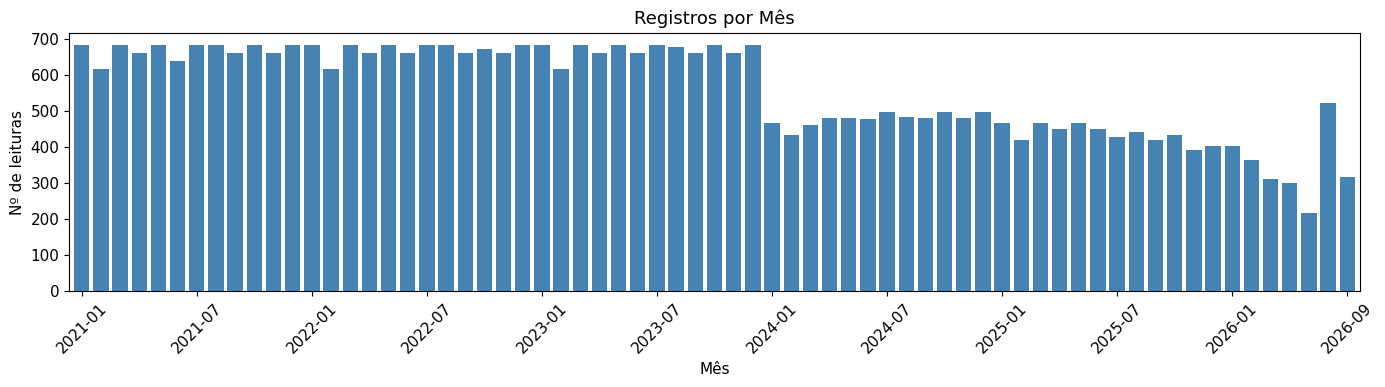

In [ ]:
# Distribuição temporal — registros por mês
df['ano_mes'] = df['data'].dt.to_period('M')
registros_mes = df.groupby('ano_mes').size()

fig, ax = plt.subplots(figsize=(14, 4))
registros_mes.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.set_title('Registros por Mês', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Nº de leituras')
ticks = ax.get_xticks()
labels = [registros_mes.index[int(t)].strftime('%Y-%m') if int(t) < len(registros_mes) else ''
          for t in ticks[::6]]
ax.set_xticks(ticks[::6])
ax.set_xticklabels(labels, rotation=45)
plt.tight_layout()
plt.show()

df.drop(columns=['ano_mes'], inplace=True, errors='ignore')

### 4.7 Gráfico: série temporal da estação principal

Gráfico de linha mostrando a **evolução diária da cota** na estação com mais registros. É o gráfico mais revelador: mostra claramente o **ciclo anual de cheia e seca** dos rios amazônicos — o nível sobe gradualmente de dezembro a junho (cheia) e desce de julho a novembro (seca). Cada "onda" no gráfico é um ano hidrológico.

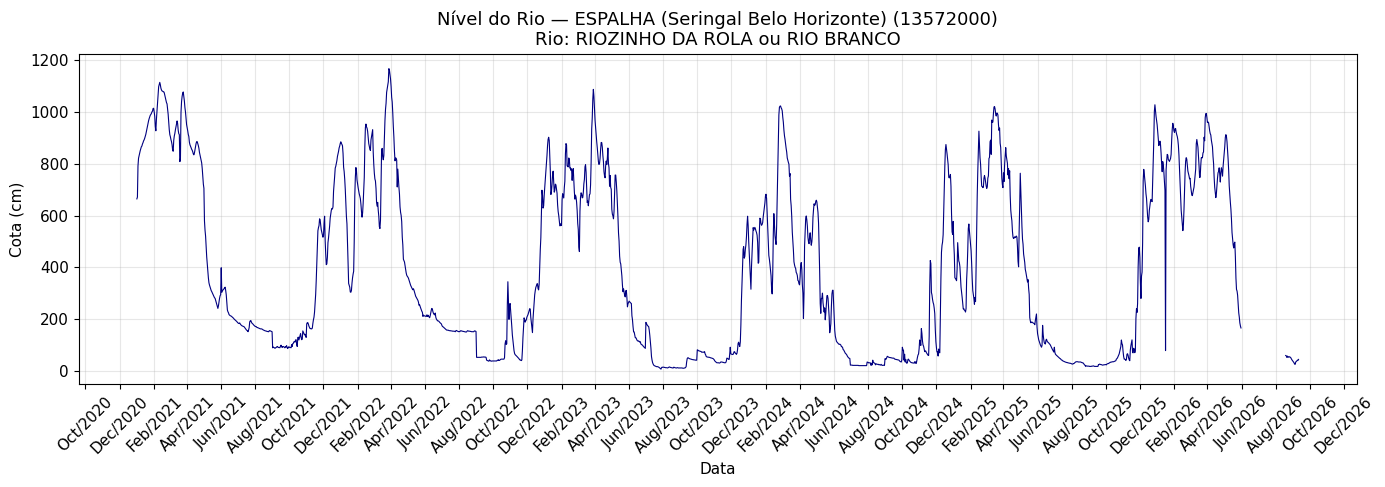

Estação: ESPALHA (Seringal Belo Horizonte) (13572000) | Rio: RIOZINHO DA ROLA ou RIO BRANCO
Período: 2021-01-01 → 2026-09-11 | 2006 registros


In [ ]:
# Série temporal — estação com mais registros
estacao_top = df['codigo_estacao'].value_counts().index[0]
nome_top = df.loc[df['codigo_estacao'] == estacao_top, 'nome_estacao'].iloc[0]
rio_top = df.loc[df['codigo_estacao'] == estacao_top, 'rio'].iloc[0]

df_est = df[df['codigo_estacao'] == estacao_top].sort_values('data')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_est['data'], df_est['cota_cm'], linewidth=0.8, color='navy')

ax.set_title(
    f'Nível do Rio — {nome_top} ({estacao_top})\nRio: {rio_top}',
    fontsize=13
)
ax.set_xlabel('Data')
ax.set_ylabel('Cota (cm)')

# Mostrar os meses no eixo X
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) ## se quiser ver todos os meses (maior precisão) basta remover o "interval=2"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

ax.grid(True, alpha=0.3)

# Rotacionar os textos para não ficarem sobrepostos
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"Estação: {nome_top} ({estacao_top}) | Rio: {rio_top}")
print(
    f"Período: {df_est['data'].min().date()} → "
    f"{df_est['data'].max().date()} | {len(df_est)} registros"
)

### 4.8 Gráfico: sazonalidade — ciclo hidrológico

Gráfico de barras com a **cota média por mês** (média de todas as estações e todos os anos). As barras azuis representam os meses de **cheia** (dez–jun) e as vermelhas os meses de **seca** (jul–nov).

Este gráfico valida que nossos dados capturam corretamente o ciclo hidrológico amazônico: os níveis mais altos devem aparecer entre maio e junho (pico da cheia) e os mais baixos entre outubro e novembro (pico da seca).

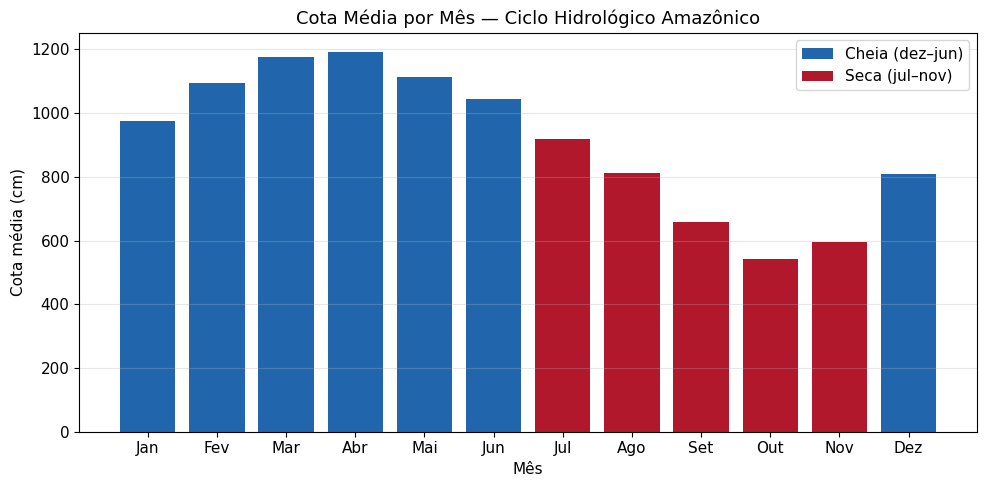

In [ ]:
# Sazonalidade — ciclo hidrológico amazônico
media_mensal = df.groupby('mes')['cota_cm'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#2166ac' if m in [12, 1, 2, 3, 4, 5, 6] else '#b2182b' for m in range(1, 13)]
ax.bar(range(1, 13), media_mensal.values, color=cores)
ax.set_title('Cota Média por Mês — Ciclo Hidrológico Amazônico', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Cota média (cm)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                     'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

legend_elements = [Patch(facecolor='#2166ac', label='Cheia (dez–jun)'),
                   Patch(facecolor='#b2182b', label='Seca (jul–nov)')]
ax.legend(handles=legend_elements, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4.9 Gráfico: distribuição da cota (histograma)

Histograma mostrando a **frequência de cada faixa de cota**. A linha vermelha tracejada marca a **mediana** (metade dos valores está abaixo, metade acima). A forma do histograma mostra se os dados têm distribuição simétrica, se há concentração em alguma faixa, ou se existem valores extremos.

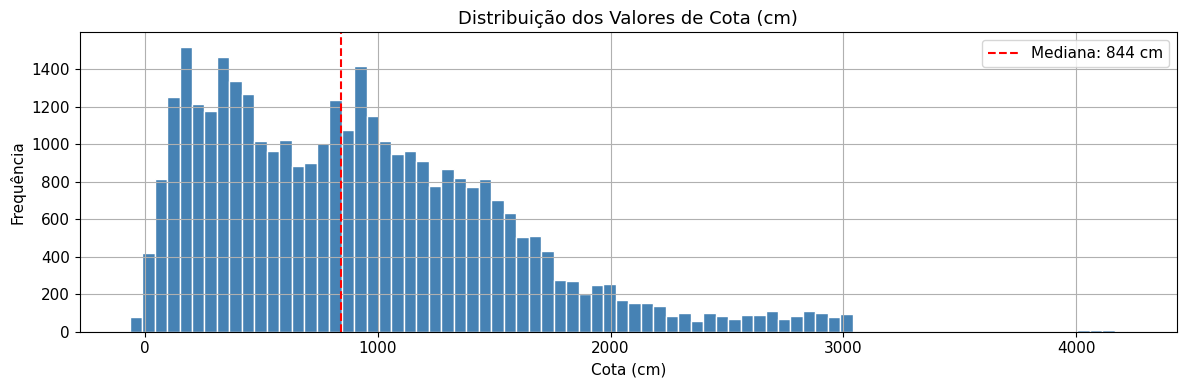

In [ ]:
# Distribuição da cota (histograma)
fig, ax = plt.subplots(figsize=(12, 4))
df['cota_cm'].dropna().hist(bins=80, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribuição dos Valores de Cota (cm)', fontsize=13)
ax.set_xlabel('Cota (cm)')
ax.set_ylabel('Frequência')
ax.axvline(df['cota_cm'].median(), color='red', linestyle='--',
           label=f"Mediana: {df['cota_cm'].median():.0f} cm")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Boxplot de cota por estação
fig, ax = plt.subplots(figsize=(14, 5))

estacoes_labels = {}
for cod in df['codigo_estacao'].unique():
    nome = df.loc[df['codigo_estacao'] == cod, 'nome_estacao'].iloc[0]
    estacoes_labels[cod] = f"{nome[:20]}\n({cod})"

data_boxplot = [df.loc[df['codigo_estacao'] == cod, 'cota_cm'].dropna().values
                for cod in df['codigo_estacao'].unique()]
labels_bp = [estacoes_labels[cod] for cod in df['codigo_estacao'].unique()]

bp = ax.boxplot(data_boxplot, tick_labels=labels_bp, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

ax.set_title('Distribuição de Cota por Estação', fontsize=13)
ax.set_ylabel('Cota (cm)')
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

## 5. Qualidade dos Dados

Seção de **auditoria** da base final. Avalia três aspectos:

1. **Completude:** Quantos valores válidos (não-nulos) cada coluna tem? A variável principal (`cota_cm`) deve estar quase 100% preenchida.
2. **Consistência temporal:** Para cada estação, qual a cobertura real? Se o período é 2021–2026 (~2.000 dias), mas a estação tem só 1.500 registros, a cobertura é 75%.
3. **Decisões de tratamento:** Lista documentada de todas as transformações aplicadas — importante para reprodutibilidade.

In [ ]:
print("=" * 60)
print(" QUALIDADE DOS DADOS")
print("=" * 60)

print(f"\n1. COMPLETUDE:")
print(f"   Registros totais: {len(df):,}")
print(f"   Cota (variável principal): {df['cota_cm'].notna().sum():,} válidos ({100*df['cota_cm'].notna().mean():.1f}%)")
if 'vazao_m3s' in df.columns:
    print(f"   Vazão: {df['vazao_m3s'].notna().sum():,} válidos ({100*df['vazao_m3s'].notna().mean():.1f}%) — apenas telemétrica")

print(f"\n2. CONSISTÊNCIA TEMPORAL:")
for cod in df['codigo_estacao'].unique():
    df_e = df[df['codigo_estacao'] == cod]
    nome = df_e['nome_estacao'].iloc[0] if 'nome_estacao' in df_e.columns else cod
    periodo = f"{df_e['data'].min().date()} → {df_e['data'].max().date()}"
    dias_esperados = (df_e['data'].max() - df_e['data'].min()).days + 1
    cobertura = len(df_e) / dias_esperados * 100 if dias_esperados > 0 else 0
    print(f"   {str(nome)[:30]:30s} | {periodo} | {len(df_e):5d} reg | cobertura: {cobertura:.0f}%")

print(f"\n3. DECISÕES DE TRATAMENTO:")
for i, d in enumerate([
    "Melt de Cota_01..Cota_31 para formato diário",
    "Dias inválidos descartados (ex: 30/fev)",
    "Leituras sem valor removidas",
    "Agregação diária da telemétrica (mediana)",
    "Deduplicação: convencional > telemétrica",
    "Outliers: cota fora de [-500, 5000] cm → NaN",
    "Enriquecimento geográfico via tabela de estações",
], 1):
    print(f"   {i}. {d}")

 QUALIDADE DOS DADOS

1. COMPLETUDE:
   Registros totais: 37,442
   Cota (variável principal): 35,095 válidos (93.7%)
   Vazão: 454 válidos (1.2%) — apenas telemétrica

2. CONSISTÊNCIA TEMPORAL:
   ESPALHA (Seringal Belo Horizon | 2021-01-01 → 2026-09-11 |  2006 reg | cobertura: 96%
   RIO ROLA (Ramal do Barro Alto) | 2021-01-01 → 2026-09-11 |  1969 reg | cobertura: 95%
   RIO BRANCO                     | 2021-01-01 → 2026-09-11 |  1970 reg | cobertura: 95%
   MISSÃO AUARIS - JUSANTE        | 2021-01-01 → 2025-10-31 |  1765 reg | cobertura: 100%
   MOCIDADE                       | 2021-01-01 → 2026-09-11 |  1975 reg | cobertura: 95%
   FAZENDA PASSARÃO               | 2021-01-01 → 2026-09-11 |  1975 reg | cobertura: 95%
   BOA VISTA                      | 2021-01-01 → 2026-09-11 |  1975 reg | cobertura: 95%
   TATU PARICATUBA                | 2021-01-01 → 2026-02-28 |  1874 reg | cobertura: 99%
   RIO CUIEIRAS                   | 2021-01-01 → 2026-02-28 |  1885 reg | cobertura: 100%
  

---

## 6. Proveniência

A **proveniência** (data lineage) documenta toda a cadeia de custódia dos dados: de onde vieram, como foram coletados, quais transformações sofreram e quando. Cada etapa gerou um arquivo JSON de proveniência:

| Arquivo | O que registra |
|---------|---------------|
| `proveniencia_estacoes.json` | Quantas estações foram buscadas, de quais UFs, em que data |
| `proveniencia_cotas.json` | Quantas requisições à API, quantos registros, endpoints usados |
| `proveniencia_tratamento.json` | Cada decisão de limpeza/transformação aplicada |

A célula abaixo carrega e exibe o conteúdo desses arquivos.

In [ ]:
for arquivo in [os.path.join(PASTA_DADOS_BRUTOS, 'proveniencia_estacoes.json'),
                os.path.join(PASTA_DADOS_BRUTOS, 'proveniencia_cotas.json'),
                os.path.join(PASTA_DADOS_TRATADOS, 'proveniencia_tratamento.json')]:
    if os.path.exists(arquivo):
        with open(arquivo, 'r', encoding='utf-8') as f:
            prov = json.load(f)
        print(f"\n{'='*50}")
        print(f" {arquivo}")
        print(f"{'='*50}")
        print(json.dumps(prov, indent=2, ensure_ascii=False))

---

## 7. Chave de Integração

A coluna **`data`** (`YYYY-MM-DD`) é a **variável em comum** para cruzamento com os dados de **preços de produtos** coletados pela equipe.

Como funciona na prática: cada linha da nossa base diz "na data X, o rio Y na estação Z estava com cota W cm". A equipe de preços tem "na data X, o produto P custava R$ V em Manaus". Com um `merge` na coluna `data`, unimos as duas informações para analisar se o nível do rio influencia os preços.

A célula abaixo mostra o código de integração e quantos dias únicos estão disponíveis.

In [ ]:
print("Exemplo de integração:")
print()
print("  df_cotas = pd.read_csv('dados_tratados/cotas_tratado.csv')")
print("  df_precos = pd.read_csv('dados_precos.csv')  # dados da equipe")
print("  df_integrado = df_cotas.merge(df_precos, on='data', how='inner')")
print()
print(f"Datas disponíveis: {df['data'].nunique()} dias únicos")
print(f"Período: {df['data'].min().date()} a {df['data'].max().date()}")

Exemplo de integração:

  df_cotas = pd.read_csv('dados_tratados/cotas_tratado.csv')
  df_precos = pd.read_csv('dados_precos.csv')  # dados da equipe
  df_integrado = df_cotas.merge(df_precos, on='data', how='inner')

Datas disponíveis: 2006 dias únicos
Período: 2021-01-01 a 2026-09-11


---

## 8. Arquivos Gerados

Resumo de todos os arquivos produzidos por este notebook:

### Dados brutos (`dados_brutos/`)

| Arquivo | Descrição |
|---------|----------|
| `inventario_estacoes_BRUTO.csv` | Todas as estações retornadas pela API (todas as UFs do Norte, todos os tipos — antes de qualquer filtro) |
| `estacoes_capitais_norte_fluviometricas.csv` | Apenas estações fluviométricas localizadas nas capitais da Região Norte (filtro final) — usadas na coleta de cotas |
| `cotas_bruto.csv` | Dados crus de nível do rio das estações das capitais, em formato largo (Cota_01..Cota_31) |
| `proveniencia_estacoes.json` | Registro de como e quando as estações foram coletadas, incluindo o filtro de tipo e de capitais aplicado |
| `proveniencia_cotas.json` | Registro de como e quando as cotas foram coletadas |
| `log_erros_coleta.json` | Estações que deram erro durante a coleta (se houver) |

### Dados tratados (`dados_tratados/`)

| Arquivo | Descrição |
|---------|----------|
| `cotas_tratado.csv` | **Base final limpa** — formato diário, 1 linha por dia por estação de capital, ~32 colunas |
| `cotas_tratado.parquet` | Mesma base em formato Parquet (binário, compacto, tipado) |
| `proveniencia_tratamento.json` | Todas as decisões de limpeza e transformação documentadas |

> **CSV vs Parquet:** CSV é texto puro (qualquer programa abre); Parquet é formato binário otimizado para big data (10x menor, leitura mais rápida, preserva tipos de dados). Ambos contêm os mesmos dados.

> **Escopo final:** toda a base tratada corresponde exclusivamente às estações fluviométricas localizadas nas capitais da Região Norte que possuíam dados disponíveis no inventário da ANA no momento da coleta.